Using device: cuda
Epoch 1: Train=84.09% | Test=45.75% || TL=0.346 | TeL=1.396
Epoch 2: Train=91.21% | Test=47.20% || TL=0.206 | TeL=1.398
Epoch 3: Train=92.75% | Test=42.64% || TL=0.172 | TeL=2.161
Epoch 4: Train=94.07% | Test=45.13% || TL=0.145 | TeL=1.847
Early stopping triggered
Best model saved.

Final Validation Accuracy: 45.13 %
Final Validation Loss: 1.847


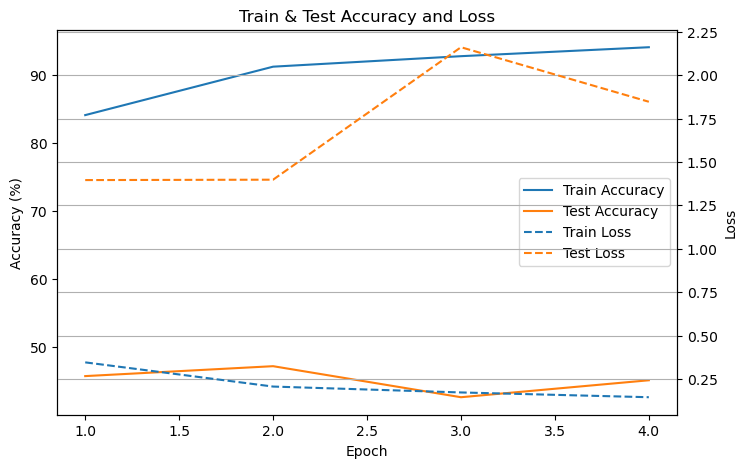

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 30
LR = 2e-4
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# 
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# DATA 
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)

val_size = int(0.2 * len(full_ds))
train_size = len(full_ds) - val_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# MODEL 
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.features[-3].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS
criterion = nn.CrossEntropyLoss()

# OPTIMIZER
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=5e-4
)

# EARLY STOPPING
best_val_loss = float("inf")
patience = 3
counter = 0
delta = 0.002

train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

# TRAINING 
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # TEST ON REAL FER DATA (IMPORTANT)
    model.eval()
    test_loss = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()

            pred = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(test_loader)
    test_acc = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    # PRINT 
    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | Test={test_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # EARLY STOPPING
    if test_loss < best_val_loss - delta:
        best_val_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("Best model saved.")

# FINAL OUTPUT 
print("\nFinal Validation Accuracy:", round(test_acc_list[-1],2), "%")
print("Final Validation Loss:", round(test_loss_list[-1],3))

#  GRAPH
epochs_range = range(1, len(train_acc_list)+1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list, label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list, linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()

Using device: cuda
Epoch 1: Train=86.56% | Test=42.64% || TL=0.299 | TeL=2.155
Epoch 2: Train=93.78% | Test=42.55% || TL=0.151 | TeL=3.170
Epoch 3: Train=95.43% | Test=46.61% || TL=0.112 | TeL=1.258
Epoch 4: Train=96.80% | Test=43.30% || TL=0.086 | TeL=3.122
Epoch 5: Train=97.50% | Test=45.86% || TL=0.068 | TeL=1.950
Epoch 6: Train=98.10% | Test=45.25% || TL=0.052 | TeL=2.607
Epoch 7: Train=98.80% | Test=46.26% || TL=0.033 | TeL=2.350
Epoch 8: Train=99.22% | Test=47.65% || TL=0.024 | TeL=2.031
Early stopping triggered
Best model saved.

Final Validation Accuracy: 47.65 %
Final Validation Loss: 2.031


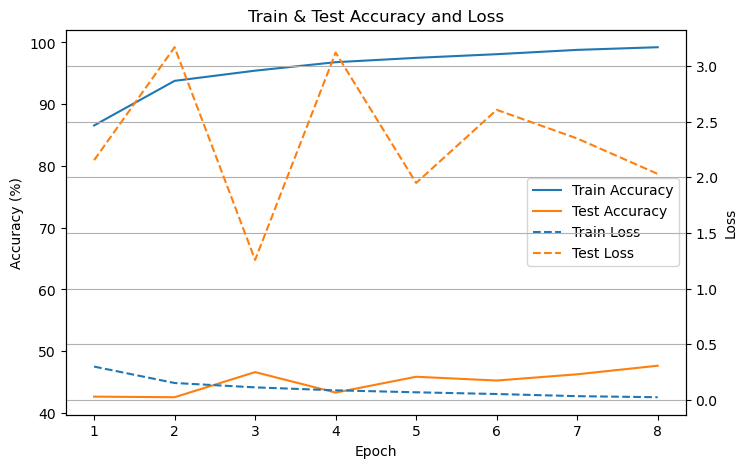

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 30
LR = 2e-4
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# SINGLE CLEAN TRANSFORM FOR ALL SPLITS
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# DATA
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=transform)

val_size   = int(0.2 * len(full_ds))
train_size = len(full_ds) - val_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last 5 layers
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.features[-3].parameters():
    param.requires_grad = True
for param in model.features[-4].parameters():
    param.requires_grad = True
for param in model.features[-5].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS
criterion = nn.CrossEntropyLoss()

# OPTIMIZER
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=5e-4
)

# SCHEDULER
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# EARLY STOPPING
best_val_loss = float("inf")
patience = 5
counter = 0
delta = 0.002

train_acc_list  = []
test_acc_list   = []
train_loss_list = []
test_loss_list  = []

# TRAINING LOOP
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pred     = out.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # TEST ON REAL FER DATA 
    model.eval()
    test_loss = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out  = model(x)
            loss = criterion(out, y)

            test_loss    += loss.item()

            pred          = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total   += y.size(0)

    test_loss /= len(test_loader)
    test_acc   = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    # STEP SCHEDULER
    scheduler.step(test_loss)

    # PRINT
    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | Test={test_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # EARLY STOPPING
    if test_loss < best_val_loss - delta:
        best_val_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("Best model saved.")

# FINAL OUTPUT
print("\nFinal Validation Accuracy:", round(test_acc_list[-1], 2), "%")
print("Final Validation Loss:",      round(test_loss_list[-1], 3))

# GRAPH
epochs_range = range(1, len(train_acc_list) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list,  label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list,  linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()

Using device: cuda
Epoch 1: Train=86.69% | Test=45.35% || TL=0.302 | TeL=1.539
Epoch 2: Train=94.17% | Test=45.30% || TL=0.150 | TeL=1.715
Epoch 3: Train=95.41% | Test=44.88% || TL=0.117 | TeL=2.237
Epoch 4: Train=96.81% | Test=45.42% || TL=0.086 | TeL=2.615
Epoch 5: Train=98.12% | Test=45.02% || TL=0.050 | TeL=2.786
Epoch 6: Train=98.60% | Test=44.12% || TL=0.040 | TeL=3.338
Epoch 7: Train=99.05% | Test=46.36% || TL=0.029 | TeL=2.382
Epoch 8: Train=99.24% | Test=45.39% || TL=0.023 | TeL=2.884
Epoch 9: Train=99.38% | Test=44.66% || TL=0.019 | TeL=2.523
Epoch 10: Train=99.46% | Test=45.63% || TL=0.018 | TeL=2.509
Epoch 11: Train=99.59% | Test=44.24% || TL=0.014 | TeL=3.379
Epoch 12: Train=99.68% | Test=44.19% || TL=0.011 | TeL=3.225
Epoch 13: Train=99.67% | Test=44.43% || TL=0.011 | TeL=3.102
Epoch 14: Train=99.61% | Test=43.30% || TL=0.012 | TeL=3.687
Epoch 15: Train=99.72% | Test=43.98% || TL=0.009 | TeL=3.328
Epoch 16: Train=99.80% | Test=44.29% || TL=0.008 | TeL=3.490
Epoch 17: Trai

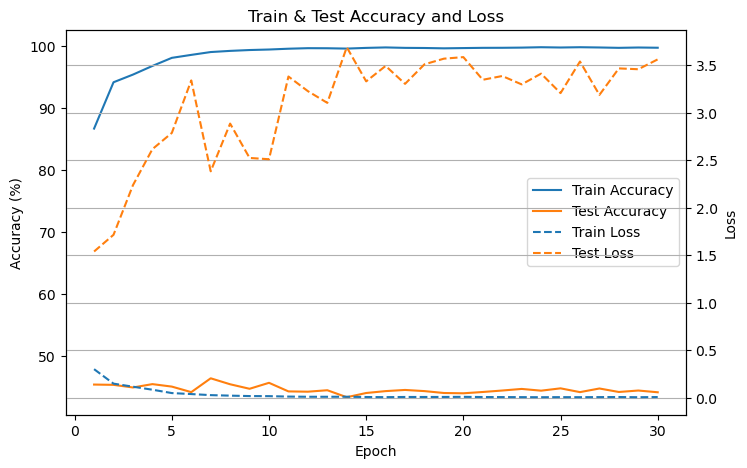

In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 30
LR = 2e-4
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# SINGLE CLEAN TRANSFORM FOR ALL SPLITS
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# DATA
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=transform)

val_size   = int(0.2 * len(full_ds))
train_size = len(full_ds) - val_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last 5 layers
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.features[-3].parameters():
    param.requires_grad = True
for param in model.features[-4].parameters():
    param.requires_grad = True
for param in model.features[-5].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS
criterion = nn.CrossEntropyLoss()

# OPTIMIZER
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=5e-4
)

# SCHEDULER
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

train_acc_list  = []
test_acc_list   = []
train_loss_list = []
test_loss_list  = []

# TRAINING LOOP
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pred     = out.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # TEST ON REAL FER DATA
    model.eval()
    test_loss = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out  = model(x)
            loss = criterion(out, y)

            test_loss    += loss.item()

            pred          = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total   += y.size(0)

    test_loss /= len(test_loader)
    test_acc   = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    # STEP SCHEDULER
    scheduler.step(test_loss)

    # PRINT
    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | Test={test_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # SAVE BEST MODEL
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        torch.save(model.state_dict(), SAVE_PATH)

print("Best model saved.")

# FINAL OUTPUT
print("\nFinal Validation Accuracy:", round(test_acc_list[-1], 2), "%")
print("Final Validation Loss:",      round(test_loss_list[-1], 3))

# GRAPH
epochs_range = range(1, len(train_acc_list) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list,  label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list,  linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()